In [1]:
## Python Notebook to Edit Plots for Learning Curves/Retroactive Interference Project

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import matplotlib.patches as patches
import os
from math import sqrt

Training Info:
#### Day 1
ExperimentVideo_2025-03-28_1611_Day1_Phase1_A_1hr_5_-2

ExperimentVideo_2025-03-28_1752_Day1_Phase_2_1hr_A_5_-2

ExperimentVideo_2025-03-29_1644_Day1_Test_1hr_A_5_-2

#### Day 2
ExperimentVideo_2025-03-29_1702_Day2_Phase1_B_1hr_4_3

ExperimentVideo_2025-03-29_1854_Day2_Phase2_B_1hr_4_3

ExperimentVideo_2025-03-30_1049_Day2_Test_B_1hr_4_3

#### Day 3
ExperimentVideo_2025-03-30_1059_Day3_Phase1_B_4hr_-1_-3

ExperimentVideo_2025-03-30_1536_Day3_Phase2_B_4hr_-1_-3

ExperimentVideo_2025-03-31_1119_Day3_Test_B_4hr_-1_-3

In [6]:
# Load the .npy file - training data
# Make sure the files 'training_path_lengths.npy' and 'training_trial_durations.npy'
# and 'training_trial_positions.npy' are in the same folder as this file

## Note: To save a figure that you generate use the savefig function below and edit the filename (dpi = 600 makes it good resolution)
## plt.savefig("filename.png", dpi=600)

# New Center =  [413.55, -268.71] # shift all data by x_pos + 413.55 and y_pos - 268.71
# Radius in pixels =  245.90

x_center = 413.55 
y_center = 268.71
radius = 245.90
ratio = 112/radius

training_path_length_data = np.load('training_path_lengths.npy', allow_pickle=True)
training_time_duration_data = np.load('training_trial_durations.npy', allow_pickle=True)
training_position_data = np.load('training_trial_positions.npy', allow_pickle=True)
positions_no_reward = np.load('positions_no_reward.npy', allow_pickle=True)

num_training_days = 3
t = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Path Length for each trial (units?) - data shape = 3 days x 10 trials
phase_1_path = []
phase_2_path = []
test_path = []

# Time duration for each trial in sec - data shape = 3 days x 10 trials
phase_1_time = []
phase_2_time = []
test_time = []

# Animal positions (x,y) throughout each trial (units?)
# Data shape = 3 days x 10 trials x 2 coordinates (x,y) (time series by duration of trial, 25fps)
phase_1_positions = []
phase_2_positions = []
test_positions = []

for i in range(3):
    # Index 0, 3, and 6 = Day 1
    # Index 1, 4, and 7 = Day 2
    # Index 2, 5, and 8 = Day 3
    phase_1_path.append(training_path_length_data[i*3][0:10])
    phase_2_path.append(training_path_length_data[i*3+1][0:10])
    test_path.append(training_path_length_data[i*3+2][0:5])
    
    phase_1_time.append(training_time_duration_data[i*3][0:10])
    phase_2_time.append(training_time_duration_data[i*3+1][0:10])
    test_time.append(training_time_duration_data[i*3+2][0:5])
    
    phase_1_positions.append(training_position_data[i*3][0:10])
    phase_2_positions.append(training_position_data[i*3+1][0:10])
    test_positions.append(training_position_data[i*3+2][0:5])

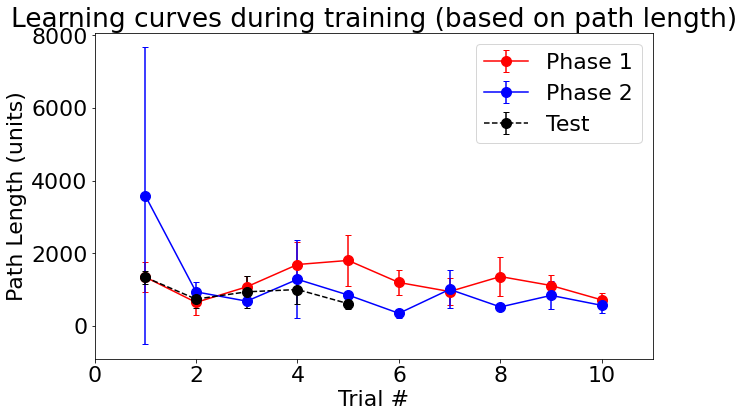

In [3]:
## Plotting Learning Curves based on path length

phase_1_mean = np.mean(phase_1_path, axis=0)
phase_1_std = np.std(phase_1_path, axis=0)

phase_2_mean = np.mean(phase_2_path, axis=0)
phase_2_std = np.std(phase_2_path, axis=0)

test_mean = np.mean(test_path, axis=0)
test_std = np.std(test_path, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")
plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Learning curves during training (based on path length)")
plt.legend()
# plt.savefig("filename.png", dpi=600)
plt.show()

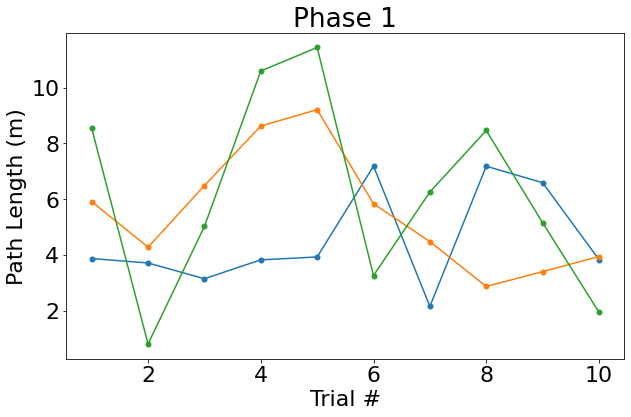

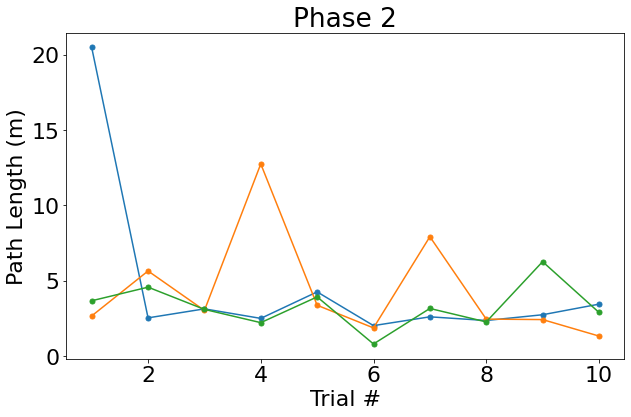

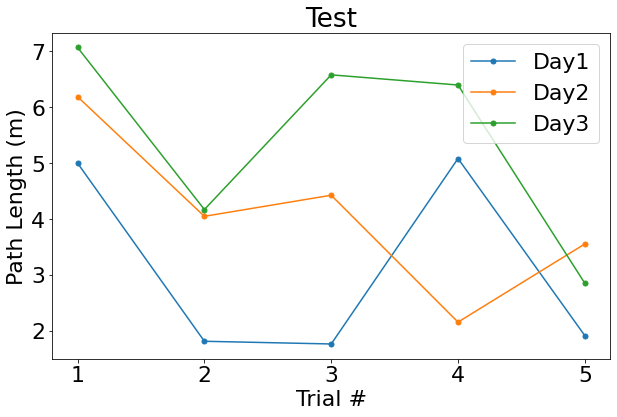

In [18]:
## Scaling individual trials

##### Code to plot each individual trial - Phase 1
num_days = 3

# set upper limit for outliers ~ 4500cm
upper_limit = 4500*ratio/100
phase1_scaled = []
phase2_scaled = []
test_scaled = []

plt.figure(figsize=(10,6))

for i in range(num_days):
    label_str = "Day" + str(i+1)
    scaled = np.array(phase_1_path[i])*ratio/100
    scaled = np.where(scaled>upper_limit, upper_limit, scaled)
    phase1_scaled.append(scaled)
    plt.plot(t, scaled, ".-", label=label_str, markersize=10)

plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
# plt.ylim([0, 4000]) # limits to keep plot scales consistent
# plt.legend()
plt.title("Phase 1")
# plt.savefig("RI_Experiment_Outputs/phase1_scaled.png", dpi=600)
plt.show()

##### Code to plot each individual trial - Phase 2

plt.figure(figsize=(10,6))

for i in range(num_days):
    label_str = "Day" + str(i+1)
    scaled = np.array(phase_2_path[i])*ratio/100
    scaled = np.where(scaled>upper_limit, upper_limit, scaled)
    phase2_scaled.append(scaled)
    plt.plot(t, scaled, ".-", label=label_str,markersize=10)

plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
# plt.ylim([0, 4000])
# plt.legend()
plt.title("Phase 2")
# plt.savefig("RI_Experiment_Outputs/phase2_scaled.png", dpi=600)
plt.show()

## Code to plot each individual trial - Test
plt.figure(figsize=(10,6))

day_index = 0

for i in range(num_days):
    label_str = "Day" + str(i+1)
    scaled = np.array(test_path[i])*ratio/100
    scaled = np.where(scaled>upper_limit, upper_limit, scaled)
    test_scaled.append(scaled)
    plt.plot(t[0:5], scaled, ".-", label=label_str,markersize=10)

plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
# plt.ylim([0, 4000])
plt.legend()
plt.title("Test")
# plt.savefig("RI_Training_Outputs/test_scaled.png", dpi=600)
plt.show()



phase_1_mean = np.mean(phase1_scaled, axis=0)
phase_1_std = np.std(phase1_scaled, axis=0)

phase_2_mean = np.mean(phase2_scaled, axis=0)
phase_2_std = np.std(phase2_scaled, axis=0)

test_mean = np.mean(test_scaled, axis=0)
test_std = np.std(test_scaled, axis=0)

# np.save("ri_training_test_trials_scaled.npy", test_scaled)

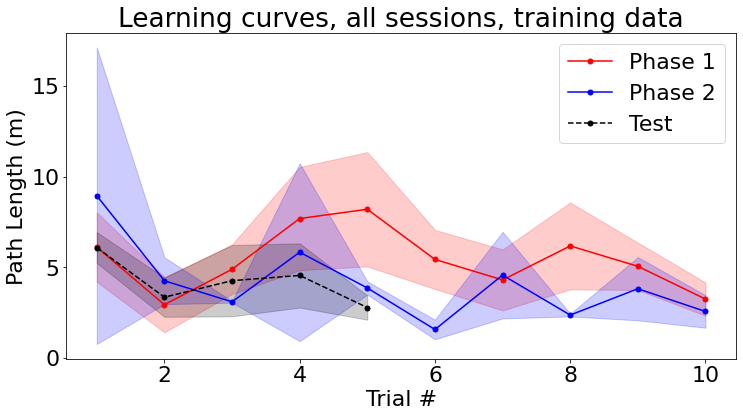

In [14]:
## Plotting Learning Curves based on path length

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

# Plot the mean line
plt.plot(t, phase_1_mean, ".-", color='red', label='Phase 1', markersize=10)
plt.fill_between(t, phase_1_mean - phase_1_std, phase_1_mean + phase_1_std, color='red', alpha=0.2)

plt.plot(t, phase_2_mean, ".-", color='blue', label='Phase 2', markersize=10)
plt.fill_between(t, phase_2_mean - phase_2_std, phase_2_mean + phase_2_std, color='blue', alpha=0.2)

plt.plot(t[0:5], test_mean, ".--", color='black', label='Test', markersize=10)
plt.fill_between(t[0:5], test_mean - test_std, test_mean + test_std, color='black', alpha=0.2)


# plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Learning curves, all sessions, training data")
plt.legend()
# plt.savefig("RI_Training_Outputs/learning-curves-all-sessions-shaded.png", dpi=600)
plt.show()

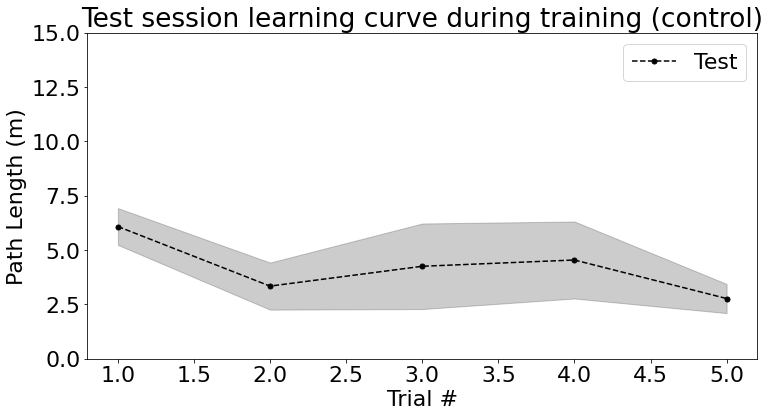

In [17]:
## Plotting Learning Curves based on path length

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

# Plot the mean line

plt.plot(t[0:5], test_mean, ".--", color='black', label='Test', markersize=10)
plt.fill_between(t[0:5], test_mean - test_std, test_mean + test_std, color='black', alpha=0.2)


# plt.xlim([0, 11]) # limits to keep plot scales consistent
plt.ylim([0, 15])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Test session learning curve during training (control)")
plt.legend()
# plt.savefig("RI_Training_Outputs/learning-curve-test-shaded.png", dpi=600)
plt.show()

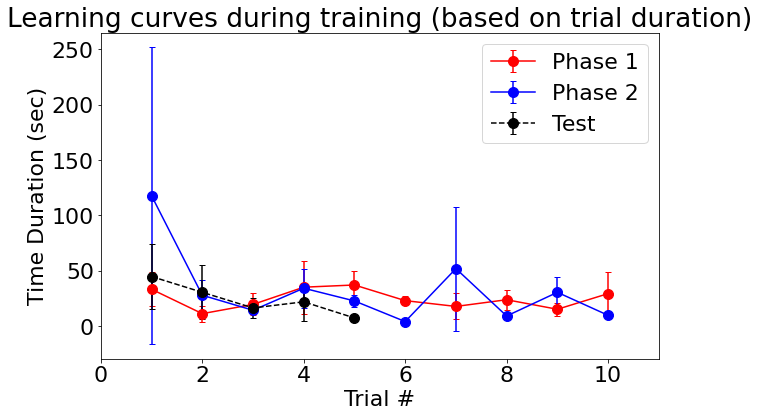

In [6]:
## Plotting Learning Curves based on trial time duration

phase_1_mean = np.mean(phase_1_time, axis=0)
phase_1_std = np.std(phase_1_time, axis=0)

phase_2_mean = np.mean(phase_2_time, axis=0)
phase_2_std = np.std(phase_2_time, axis=0)

test_mean = np.mean(test_time, axis=0)
test_std = np.std(test_time, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")
plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Time Duration (sec)")
plt.title("Learning curves during training (based on trial duration)")
plt.legend()
# plt.savefig("filename.png", dpi=600)
plt.show()

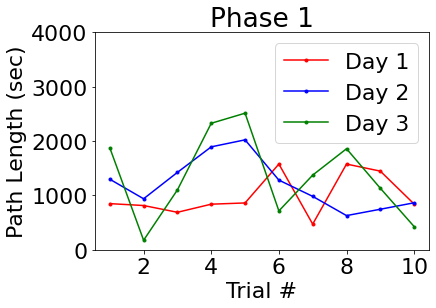

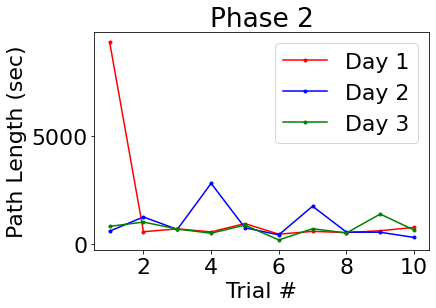

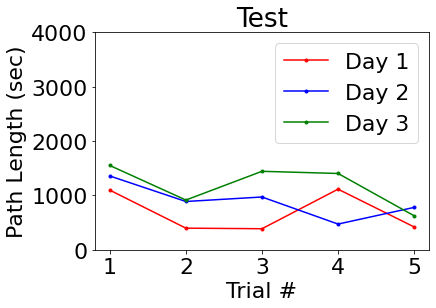

In [7]:
##### Code to plot each individual trial - Phase 1

day_index = 0

plt.plot(t, phase_1_path[day_index], "r.-", label="Day 1")
plt.plot(t, phase_1_path[day_index+1], "b.-", label="Day 2")
plt.plot(t, phase_1_path[day_index+2], "g.-", label="Day 3")

plt.xlabel("Trial #")
plt.ylabel("Path Length (sec)")
plt.ylim([0, 4000]) # limits to keep plot scales consistent
plt.legend()
plt.title("Phase 1")
plt.show()

##### Code to plot each individual trial - Phase 2

day_index = 0

plt.plot(t, phase_2_path[day_index], "r.-", label="Day 1")
plt.plot(t, phase_2_path[day_index+1], "b.-", label="Day 2")
plt.plot(t, phase_2_path[day_index+2], "g.-", label="Day 3")

plt.xlabel("Trial #")
plt.ylabel("Path Length (sec)")
# plt.ylim([0, 4000])
plt.legend()
plt.title("Phase 2")
plt.show()

## Code to plot each individual trial - Test

day_index = 0

plt.plot(t[0:5], test_path[day_index], "r.-", label="Day 1")
plt.plot(t[0:5], test_path[day_index+1], "b.-", label="Day 2")
plt.plot(t[0:5], test_path[day_index+2], "g.-", label="Day 3")

plt.xlabel("Trial #")
plt.ylabel("Path Length (sec)")
plt.ylim([0, 4000])
plt.legend()
plt.title("Test")
plt.show()


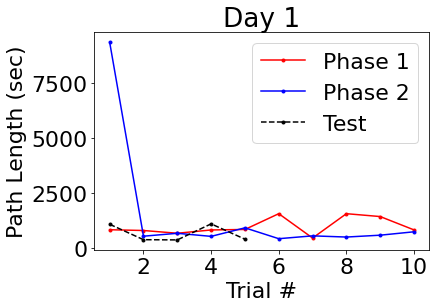

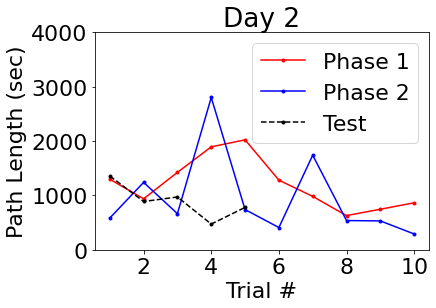

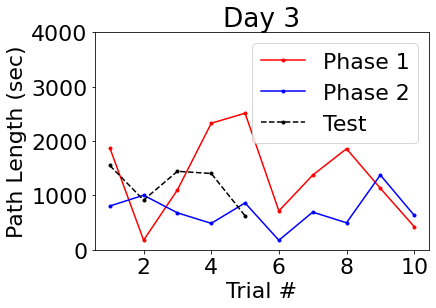

In [8]:
##### Code to plot each individual trial - Day 1

day_index = 0

plt.plot(t, phase_1_path[day_index], "r.-", label="Phase 1")
plt.plot(t, phase_2_path[day_index], "b.-", label="Phase 2")
plt.plot(t[0:5], test_path[day_index], "k.--", label="Test")

plt.xlabel("Trial #")
plt.ylabel("Path Length (sec)")
# plt.ylim([0, 4000])
plt.legend()
plt.title("Day 1")
plt.show()

##### Code to plot each individual trial - Day 2

day_index = 1

plt.plot(t, phase_1_path[day_index], "r.-", label="Phase 1")
plt.plot(t, phase_2_path[day_index], "b.-", label="Phase 2")
plt.plot(t[0:5], test_path[day_index], "k.--", label="Test")

plt.xlabel("Trial #")
plt.ylabel("Path Length (sec)")
plt.ylim([0, 4000]) # limits to keep plot scales consistent
plt.legend()
plt.title("Day 2")
plt.show()

##### Code to plot each individual trial - Day 3

day_index = 2

plt.plot(t, phase_1_path[day_index], "r.-", label="Phase 1")
plt.plot(t, phase_2_path[day_index], "b.-", label="Phase 2")
plt.plot(t[0:5], test_path[day_index], "k.--", label="Test")

plt.xlabel("Trial #")
plt.ylabel("Path Length (sec)")
plt.ylim([0, 4000]) # limits to keep plot scales consistent
plt.legend()
plt.title("Day 3")
plt.show()


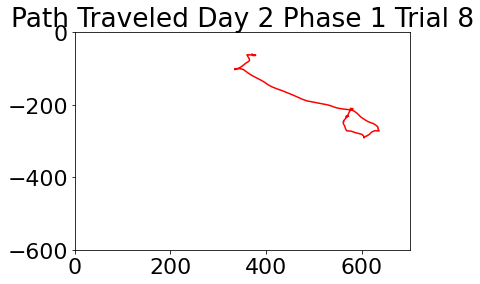

In [9]:
## Sample Plotting Single Position Data Trial

day_num = 1 # ranges 0 to 2
trial_num = 7 # ranges 0 to 9 (or 0 to 4 for test session)

## Code to plot one single path traversal
# sample code for phase 1 data
x = phase_1_positions[day_num][trial_num][0] # x positions
y = phase_1_positions[day_num][trial_num][1] # y positions

plt.plot(x,y,color="red")
plt.xlim([0, 700]) # limits to keep plot scales consistent
plt.ylim([-600, 0])
plt.title("Path Traveled Day %s Phase 1 Trial %s" % (day_num+1, trial_num+1)) # Using special string formatting
plt.show()

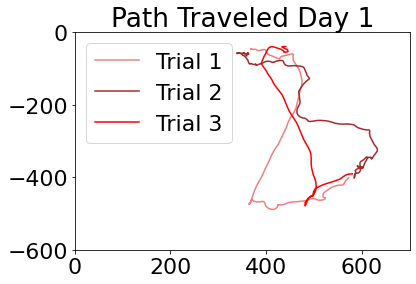

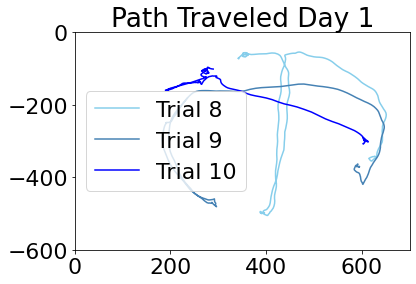

In [10]:
## Sample Plotting Position Data for Trials

red_colors = ["lightcoral", "brown", "red"]
blue_colors = ["skyblue", "steelblue", "blue"]

day_num = 0
trial_num = 0

for i in range(3): # first 3 trials
    x = phase_1_positions[day_num][i][0] # x positions
    y = phase_1_positions[day_num][i][1] # y positions
    plt.plot(x,y, color=red_colors[i], label = str("Trial " + str(i+1)))

plt.xlim([0, 700])
plt.ylim([-600, 0])
plt.legend()
plt.title("Path Traveled Day %s" % (day_num+1))
plt.show()

for i in [7,8,9]: # last 3 trials
    x = phase_1_positions[day_num][i][0] # x positions
    y = phase_1_positions[day_num][i][1] # y positions
    plt.plot(x,y, color=blue_colors[i%7], label = str("Trial " + str(i+1)))
    
plt.xlim([0, 700])
plt.ylim([-600, 0])
plt.legend()
plt.title("Path Traveled Day %s" % (day_num+1))
plt.show()

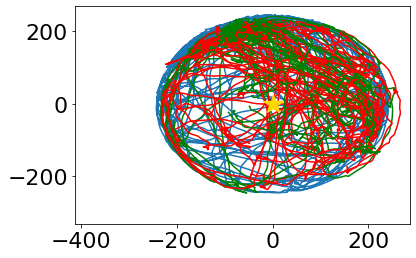

Trial count =  30


In [34]:
# Finding units of the cheeseboard

x = positions_no_reward[0] - x_center
y = positions_no_reward[1] - y_center

plt.plot(x,y)

count = 0

for i in range(10):
    for k in range(3):
        x = phase_1_positions[k][i][0] - x_center # x positions
        y = phase_1_positions[k][i][1] - y_center # y positions
        plt.plot(x,y,color="red")
        
        x = phase_2_positions[k][i][0] - x_center # x positions
        y = phase_2_positions[k][i][1] - y_center # y positions
        plt.plot(x,y,color="green")
        
        count += 1
        
plt.plot(x_center - x_center, y_center - y_center, "*", color="gold", markersize=20)
plt.xlim([0, 700] - x_center)
plt.ylim([-600, 0] - y_center)
plt.show()
print("Trial count = ", count)

In [38]:
x = positions_no_reward[0]
y = positions_no_reward[1]

print("x ---", "max = ", np.max(x), "min = ", np.min(x))

print("y ---", "max = ", np.max(y), "min = ", np.min(y))

x_center = np.mean([np.max(x), np.min(x)])
y_center = np.mean([np.max(y), np.min(y)])

x_diam = np.max(x) - np.min(x)
y_diam = np.max(y) - np.min(y)

radius = np.max([x_diam,y_diam])/2

print("New Center = ", x_center, y_center)

print("X and Y diameter = ", x_diam, y_diam)

print("Radius in pixels = ", radius)

x --- max =  656.6863213699668 min =  170.41989589011555
y --- max =  -22.8190537880864 min =  -514.6103095041823
New Center =  413.55310863004115 -268.71468164613435
X and Y diameter =  486.26642547985125 491.79125571609586
Radius in pixels =  245.89562785804793


In [11]:
## Path Length Function used to calculate path length from time series (x,y) animal postion data

def pathlength(x,y):
    n = len(x) 
    lv = [sqrt((x[i]-x[i-1])**2 + (y[i]-y[i-1])**2) for i in range (1,n)]
    L = sum(lv)
    return L